In [1]:
# imports
import os, sys, json, shutil
from pathlib import Path

import numpy as np
import pandas as pd
import SimpleITK as sitk
import yaml
from tqdm.auto import tqdm
from rich import print as rprint
from rich.console import Console
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

with open(ROOT / "config.yaml") as f:
    cfg = yaml.safe_load(f)

IMAGES_DIR   = ROOT / cfg["paths"]["images_raw"]
LABELS_DIR   = ROOT / cfg["paths"]["labels_raw"]
PROC_IMGS    = ROOT / cfg["paths"]["processed_imgs"]
PROC_LBLS    = ROOT / cfg["paths"]["processed_lbl"]
SPLITS_DIR   = ROOT / cfg["paths"]["splits"]
GRAPHS_DIR   = ROOT / cfg["paths"]["graphs"]

for d in [PROC_IMGS, PROC_LBLS, SPLITS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

console = Console()
IMG_SFX = cfg["data"]["image_suffix"]
LBL_SFX = cfg["data"]["label_suffix"]
SEED    = cfg["project"]["seed"]
np.random.seed(SEED)

rprint("[bold green]Config OK.[/] Preprocessing will write to:")
rprint(f"  Images → [cyan]{PROC_IMGS}[/]")
rprint(f"  Labels → [cyan]{PROC_LBLS}[/]")

Config OK. Preprocessing will write to:

Images → /home/saber/internships/assignments/cbct/data/processed/images

Labels → /home/saber/internships/assignments/cbct/data/processed/labels

In [2]:
# build case list
img_files = sorted(IMAGES_DIR.glob(f"*{IMG_SFX}"))
lbl_files = sorted(LABELS_DIR.glob(f"*{LBL_SFX}"))

def case_id(p: Path, sfx: str) -> str:
    return p.name.replace(sfx, "")

img_map = {case_id(p, IMG_SFX): p for p in img_files}
lbl_map = {case_id(p, LBL_SFX): p for p in lbl_files}
cases   = sorted(set(img_map) & set(lbl_map))

rprint(f"Total cases: [bold]{len(cases)}[/]")

Total cases: 480

In [3]:
# label mapping
# ToothFairy2 encodes FDI notation directly as label values.
# We need to map them to contiguous 0-based indices for one-hot / cross-entropy.
# From EDA: present label IDs are:
#   0 (background), 1-7 (lower front), 8-17 (premolars/molars lower),
#   21-28 (upper), 31-38 (upper back), 41-48 (lower back)
# This IS the FDI scheme: tens digit = quadrant (1-4), units = tooth position (1-8)
#
# We also have jaw labels: per dataset.json these are encoded as large values
# Checking what the actual non-tooth labels are:

from collections import Counter
label_counter = Counter()
for cid in cases[:20]:   # sample first 20 for speed
    arr = sitk.GetArrayFromImage(sitk.ReadImage(str(lbl_map[cid])))
    for v in np.unique(arr):
        label_counter[int(v)] += 1

all_label_ids = sorted(label_counter.keys())
print("Observed label IDs (sample of 20 cases):", all_label_ids)
print("Total unique labels:", len(all_label_ids))

Observed label IDs (sample of 20 cases): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 21, 22, 23, 24, 25, 26, 27, 28, 31, 32, 33, 34, 35, 36, 37, 38, 41, 42, 43, 44, 45, 46, 47, 48]
Total unique labels: 43


In [4]:
# define label mapping
# FDI standard teeth: 11-18, 21-28, 31-38, 41-48  (32 teeth total)
# ToothFairy2 encodes them as 1-48 with gaps.
# We build a remapping: raw_label_id -> contiguous_index

# From full EDA label_frequency.csv:
RAW_LABELS = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,
              21,22,23,24,25,26,27,28,
              31,32,33,34,35,36,37,38,
              41,42,43,44,45,46,47,48]

# Build forward & reverse maps
LABEL_TO_IDX = {raw: idx for idx, raw in enumerate(RAW_LABELS)}
IDX_TO_LABEL = {idx: raw for raw, idx in LABEL_TO_IDX.items()}

print(f"Number of classes (incl. background): {len(LABEL_TO_IDX)}")
print("\nMapping preview (raw → index):")
for raw, idx in list(LABEL_TO_IDX.items())[:10]:
    print(f"  raw={raw:2d}  →  idx={idx:2d}")

# Save mapping for use in training
import json
mapping = {"label_to_idx": LABEL_TO_IDX, "idx_to_label": IDX_TO_LABEL,
           "num_classes": len(LABEL_TO_IDX), "raw_labels": RAW_LABELS}
with open(SPLITS_DIR / "label_mapping.json", "w") as f:
    json.dump(mapping, f, indent=2)
rprint(f"[green]Saved label_mapping.json[/]")

Number of classes (incl. background): 43

Mapping preview (raw → index):
  raw= 0  →  idx= 0
  raw= 1  →  idx= 1
  raw= 2  →  idx= 2
  raw= 3  →  idx= 3
  raw= 4  →  idx= 4
  raw= 5  →  idx= 5
  raw= 6  →  idx= 6
  raw= 7  →  idx= 7
  raw= 8  →  idx= 8
  raw= 9  →  idx= 9


Saved label_mapping.json

In [5]:
# train/val/test split
from sklearn.model_selection import train_test_split

train_r = cfg["split"]["train"]
val_r   = cfg["split"]["val"]
test_r  = cfg["split"]["test"]

# First split off test set, then split remainder into train/val
train_val, test_cases = train_test_split(cases,
                                          test_size=test_r,
                                          random_state=SEED)
val_adjusted = val_r / (train_r + val_r)   # relative size within train_val
train_cases, val_cases = train_test_split(train_val,
                                           test_size=val_adjusted,
                                           random_state=SEED)

print(f"Train : {len(train_cases)} ({len(train_cases)/len(cases)*100:.1f}%)")
print(f"Val   : {len(val_cases)}  ({len(val_cases)/len(cases)*100:.1f}%)")
print(f"Test  : {len(test_cases)} ({len(test_cases)/len(cases)*100:.1f}%)")

# Save splits
splits = {"train": train_cases, "val": val_cases, "test": test_cases}
with open(SPLITS_DIR / "splits.json", "w") as f:
    json.dump(splits, f, indent=2)
rprint(f"[green]Saved splits.json[/]")

Train : 336 (70.0%)
Val   : 72  (15.0%)
Test  : 72 (15.0%)


Saved splits.json

In [6]:
# helper functions
def load_volume(path: Path):
    """Load .mha via SimpleITK, return (array Z×Y×X, sitk_image)."""
    img = sitk.ReadImage(str(path))
    arr = sitk.GetArrayFromImage(img).astype(np.float32)
    return arr, img

def clip_and_normalize(arr: np.ndarray,
                       clip_lo: float = -1000,
                       clip_hi: float = 3000,
                       out_lo: float = -1,
                       out_hi: float = 1) -> np.ndarray:
    """Clip HU values then linearly normalize to [out_lo, out_hi]."""
    arr = np.clip(arr, clip_lo, clip_hi)
    arr = (arr - clip_lo) / (clip_hi - clip_lo)       # [0, 1]
    arr = arr * (out_hi - out_lo) + out_lo             # [out_lo, out_hi]
    return arr.astype(np.float32)

def remap_labels(lbl_arr: np.ndarray, label_to_idx: dict) -> np.ndarray:
    """Remap raw FDI label IDs to contiguous indices. Unknown IDs → 0."""
    out = np.zeros_like(lbl_arr, dtype=np.uint8)
    for raw, idx in label_to_idx.items():
        out[lbl_arr == raw] = idx
    return out

def save_volume(arr: np.ndarray, ref_img: sitk.Image, out_path: Path,
                is_label: bool = False):
    """Save numpy array back to .mha preserving spacing/origin/direction."""
    out_img = sitk.GetImageFromArray(arr)
    out_img.SetSpacing(ref_img.GetSpacing())
    out_img.SetOrigin(ref_img.GetOrigin())
    out_img.SetDirection(ref_img.GetDirection())
    if is_label:
        out_img = sitk.Cast(out_img, sitk.sitkUInt8)
    sitk.WriteImage(out_img, str(out_path), useCompression=True)

rprint("[bold green]Preprocessing functions defined.[/]")

Preprocessing functions defined.

Raw image  : shape=(262, 512, 512)  min=-1000  max=3476
Raw label  : shape=(262, 512, 512)  unique=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 21, 22, 23, 24, 25, 27, 31, 32, 33, 34, 35, 41, 42, 43, 44, 45, 47]

Proc image : min=-1.000  max=1.000  dtype=float32
Proc label : unique indices=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 19, 20, 21, 22, 23, 25, 27, 28, 29, 30, 31, 35, 36, 37, 38, 39, 41]  dtype=uint8


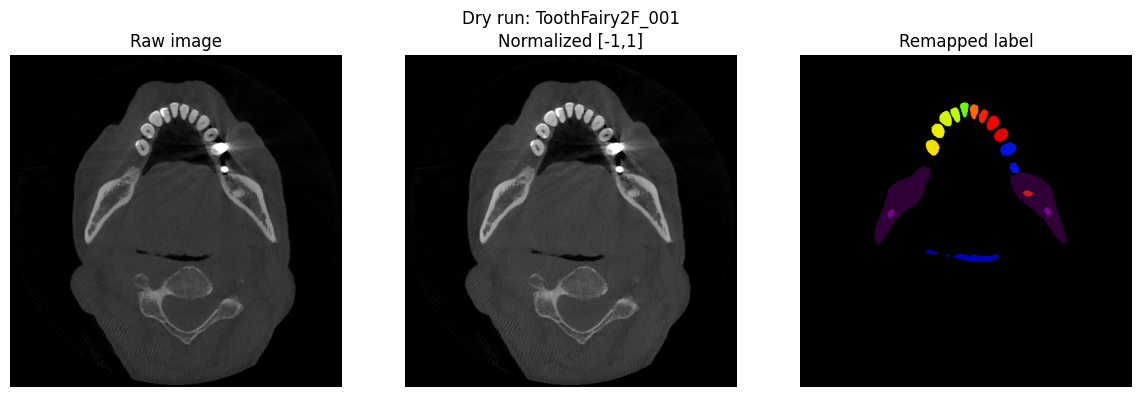

In [7]:
# sanity check - dry run
cid = cases[0]
img_arr, img_ref = load_volume(img_map[cid])
lbl_arr, lbl_ref = load_volume(lbl_map[cid])
lbl_arr = lbl_arr.astype(np.int32)

print(f"Raw image  : shape={img_arr.shape}  min={img_arr.min():.0f}  max={img_arr.max():.0f}")
print(f"Raw label  : shape={lbl_arr.shape}  unique={np.unique(lbl_arr).tolist()}")

# apply pipeline
img_proc = clip_and_normalize(img_arr,
                               cfg["data"]["intensity_clip"][0],
                               cfg["data"]["intensity_clip"][1],
                               cfg["data"]["intensity_norm"][0],
                               cfg["data"]["intensity_norm"][1])
lbl_proc = remap_labels(lbl_arr, LABEL_TO_IDX)

print(f"\nProc image : min={img_proc.min():.3f}  max={img_proc.max():.3f}  dtype={img_proc.dtype}")
print(f"Proc label : unique indices={np.unique(lbl_proc).tolist()}  dtype={lbl_proc.dtype}")

# Visual sanity check
zi = img_arr.shape[0] // 2
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img_arr[zi], cmap="gray"); axes[0].set_title("Raw image"); axes[0].axis("off")
axes[1].imshow(img_proc[zi], cmap="gray"); axes[1].set_title("Normalized [-1,1]"); axes[1].axis("off")
axes[2].imshow(lbl_proc[zi], cmap="nipy_spectral", vmin=0, vmax=len(LABEL_TO_IDX))
axes[2].set_title("Remapped label"); axes[2].axis("off")
plt.suptitle(f"Dry run: {cid}")
plt.tight_layout()
plt.savefig(GRAPHS_DIR / "preprocessing_dryrun.png", dpi=130)
plt.show()

In [8]:
# running full preprocessing pipeline
# NOTE: keep original spacing (0.3mm isotropic - perfect as-is from EDA).
# Only: clip+normalize images, remap label IDs, save compressed .mha.
# Cropping/patching is handled at train time by MONAI's RandCropByPosNegLabel.

CLIP_LO  = cfg["data"]["intensity_clip"][0]
CLIP_HI  = cfg["data"]["intensity_clip"][1]
NORM_LO  = cfg["data"]["intensity_norm"][0]
NORM_HI  = cfg["data"]["intensity_norm"][1]

failed = []

for cid in tqdm(cases, desc="Preprocessing"):
    img_out = PROC_IMGS / f"{cid}.mha"
    lbl_out = PROC_LBLS / f"{cid}.mha"

    # skip if already done
    if img_out.exists() and lbl_out.exists():
        continue

    try:
        img_arr, img_ref = load_volume(img_map[cid])
        lbl_arr, lbl_ref = load_volume(lbl_map[cid])
        lbl_arr = lbl_arr.astype(np.int32)

        img_proc = clip_and_normalize(img_arr, CLIP_LO, CLIP_HI, NORM_LO, NORM_HI)
        lbl_proc = remap_labels(lbl_arr, LABEL_TO_IDX)

        save_volume(img_proc, img_ref, img_out, is_label=False)
        save_volume(lbl_proc, lbl_ref, lbl_out, is_label=True)

    except Exception as e:
        rprint(f"[red]FAILED[/] {cid}: {e}")
        failed.append(cid)

rprint(f"\n[bold green]Done.[/] Processed {len(cases) - len(failed)}/{len(cases)} cases.")
if failed:
    rprint(f"[red]Failed cases:[/] {failed}")

Preprocessing:   0%|          | 0/480 [00:00<?, ?it/s]

Done. Processed 480/480 cases.

In [9]:
# verify output contents
proc_imgs = sorted(PROC_IMGS.glob("*.mha"))
proc_lbls = sorted(PROC_LBLS.glob("*.mha"))

print(f"Processed images : {len(proc_imgs)}")
print(f"Processed labels : {len(proc_lbls)}")

# spot-check one processed file
sample = proc_imgs[0]
arr = sitk.GetArrayFromImage(sitk.ReadImage(str(sample)))
print(f"\nSample: {sample.name}")
print(f"  Shape : {arr.shape}")
print(f"  Range : [{arr.min():.3f}, {arr.max():.3f}]")
print(f"  Dtype : {arr.dtype}")

Processed images : 480
Processed labels : 480

Sample: ToothFairy2F_001.mha
  Shape : (262, 512, 512)
  Range : [-1.000, 1.000]
  Dtype : float32


In [10]:
# build MONAI-compatible dataset dicts
# MONAI DataLoader expects a list of {"image": path, "label": path} dicts.

def make_manifest(case_ids, split_name):
    entries = []
    for cid in case_ids:
        entries.append({
            "image": str(PROC_IMGS / f"{cid}.mha"),
            "label": str(PROC_LBLS / f"{cid}.mha"),
            "case_id": cid
        })
    out_path = SPLITS_DIR / f"{split_name}.json"
    with open(out_path, "w") as f:
        json.dump(entries, f, indent=2)
    rprint(f"[green]Saved {split_name}.json[/] ({len(entries)} cases)")
    return entries

train_manifest = make_manifest(train_cases, "train")
val_manifest   = make_manifest(val_cases,   "val")
test_manifest  = make_manifest(test_cases,  "test")

rprint(f"\nManifests saved to [cyan]{SPLITS_DIR}[/]")

Saved train.json (336 cases)

Saved val.json (72 cases)

Saved test.json (72 cases)

Manifests saved to /home/saber/internships/assignments/cbct/data/processed/splits

Computing class weights:   0%|          | 0/50 [00:00<?, ?it/s]

Class weights (first 10):
  idx= 0  raw_label= 0  freq=0.89536  weight=0.00
  idx= 1  raw_label= 1  freq=0.06648  weight=0.00
  idx= 2  raw_label= 2  freq=0.00135  weight=0.16
  idx= 3  raw_label= 3  freq=0.00063  weight=0.34
  idx= 4  raw_label= 4  freq=0.00062  weight=0.34
  idx= 5  raw_label= 5  freq=0.00003  weight=7.70
  idx= 6  raw_label= 6  freq=0.00005  weight=4.22
  idx= 7  raw_label= 7  freq=0.02000  weight=0.01
  idx= 8  raw_label= 8  freq=0.00009  weight=2.33
  idx= 9  raw_label= 9  freq=0.00074  weight=0.28


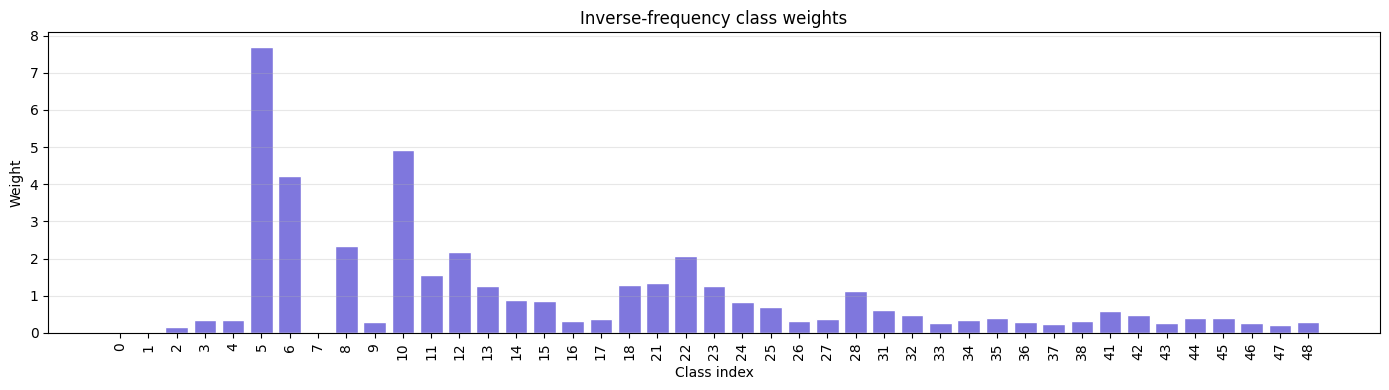

Saved class_weights.json

In [11]:
# class weight computation
# Count total voxels per class across training set (sampled for speed)
# Used to compute inverse-frequency weights for Dice+CE loss

from collections import defaultdict

class_voxels = defaultdict(int)
sample_train = train_cases[:min(50, len(train_cases))]  # sample 50 for speed

for cid in tqdm(sample_train, desc="Computing class weights"):
    arr = sitk.GetArrayFromImage(sitk.ReadImage(str(PROC_LBLS / f"{cid}.mha")))
    for idx in range(len(LABEL_TO_IDX)):
        class_voxels[idx] += int((arr == idx).sum())

total_vox = sum(class_voxels.values())
num_cls   = len(LABEL_TO_IDX)

# Inverse frequency weights, normalized so they sum to num_classes
freq    = np.array([class_voxels[i] / total_vox for i in range(num_cls)])
weights = (1.0 / (freq + 1e-6))
weights = weights / weights.mean()   # normalize around 1.0

print("Class weights (first 10):")
for i in range(min(10, num_cls)):
    raw_lbl = IDX_TO_LABEL[i]
    print(f"  idx={i:2d}  raw_label={raw_lbl:2d}  freq={freq[i]:.5f}  weight={weights[i]:.2f}")

# Save weights
weight_dict = {str(i): float(weights[i]) for i in range(num_cls)}
with open(SPLITS_DIR / "class_weights.json", "w") as f:
    json.dump(weight_dict, f, indent=2)

# Plot
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(num_cls), weights, color="#7F77DD", edgecolor="white")
ax.set_xlabel("Class index"); ax.set_ylabel("Weight")
ax.set_title("Inverse-frequency class weights")
ax.set_xticks(range(num_cls))
ax.set_xticklabels([str(IDX_TO_LABEL[i]) for i in range(num_cls)], rotation=90)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(GRAPHS_DIR / "class_weights.png", dpi=150)
plt.show()
rprint("[green]Saved class_weights.json[/]")

>Class weight distribution confirms severe imbalance. Background (idx=0) dominates at 89.5% of all voxels - weight≈0. Jaw bone (idx=1) is 6.6%. Individual teeth are tiny fractions: rare teeth (idx=5,6,8) get weights up to 7.7×. The weighted loss will be critical for learning rare teeth.

In [12]:
# summary
console.rule("[bold]Preprocessing Summary")
rprint(f"Total cases : [bold]{len(cases)}[/]")
rprint(f"Train / Val / Test : {len(train_cases)} / {len(val_cases)} / {len(test_cases)}")
rprint(f"Spacing : kept at 0.3 mm isotropic (no resampling needed)")
rprint(f"Intensity clipping : [{CLIP_LO}, {CLIP_HI}] HU → normalized to [{NORM_LO}, {NORM_HI}]")
rprint(f"Label remapping : {len(LABEL_TO_IDX)} classes (raw FDI IDs → 0-based indices)")
rprint(f"Cropping/patching : deferred to MONAI transforms at train time")
rprint(f"\nOutputs:")
rprint(f"[cyan]{PROC_IMGS}[/]({len(proc_imgs)} files)")
rprint(f"[cyan]{PROC_LBLS}[/]({len(proc_lbls)} files)")
rprint(f"[cyan]{SPLITS_DIR}/train.json / val.json / test.json[/]")
rprint(f"[cyan]{SPLITS_DIR}/label_mapping.json[/]")
rprint(f"[cyan]{SPLITS_DIR}/class_weights.json[/]")

────────────────────────────────────────────── Preprocessing Summary ──────────────────────────────────────────────

Total cases : 480

Train / Val / Test : 336 / 72 / 72

Spacing : kept at 0.3 mm isotropic (no resampling needed)

Intensity clipping : [-1000, 3000] HU → normalized to [-1, 1]

...

/home/saber/internships/assignments/cbct/data/processed/images(480 files)

/home/saber/internships/assignments/cbct/data/processed/labels(480 files)

/home/saber/internships/assignments/cbct/data/processed/splits/train.json / val.json / test.json

/home/saber/internships/assignments/cbct/data/processed/splits/label_mapping.json

/home/saber/internships/assignments/cbct/data/processed/splits/class_weights.json